In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)  # for reproducibility

n = 200
square_feet = np.random.normal(loc=1500, scale=300, size=n)

# True relationship: price = 50,000 + 150 * square_feet + noise
true_intercept = 50000
true_slope = 150
noise = np.random.normal(loc=0, scale=20000, size=n)

price = true_intercept + true_slope * square_feet + noise

df = pd.DataFrame({
    "square_feet": square_feet,
    "price": price

})

df.head()

,square_feet,price
0,1649.014246,304507.884092
1,1458.520710,279993.796975
2,1694.306561,325807.009078
3,1956.908957,364612.384579
4,1429.753988,236909.710778


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   square_feet  200 non-null    float64
 1   price        200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


,square_feet,price
count,200.000000,200.000000
mean,1487.768710,274882.670305
std,279.301175,47981.784703
min,714.076469,137481.297295
25%,1288.461698,244843.592025
50%,1498.742435,279944.684923
75%,1650.255742,306254.946532
max,2316.050750,402116.087782


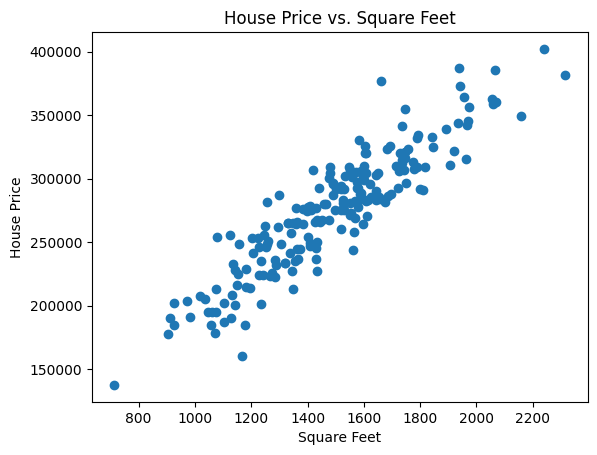

,square_feet,price
square_feet,1.000000,0.912292
price,0.912292,1.000000


In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["square_feet"], df["price"])
plt.xlabel("Square Feet")
plt.ylabel("House Price")
plt.title("House Price vs. Square Feet")
plt.show()

df[["square_feet", "price"]].corr()

Correlation (Pearson’s r):
• Measures strength and direction of linear relationship between X and Y.
• r ranges from –1 to +1.
• |r| near 1 → strong linear pattern.
• r near 0 → weak or no linear pattern.

BUT:
• Correlation is symmetric: corr(X, Y) = corr(Y, X).
• Correlation does NOT give a prediction equation.

Simple linear regression:
Y-hat = β₀ + β₁ X

Connection to correlation:
β₁ = r * (s_Y / s_X)

Where:
• r = correlation between X and Y
• s_X = standard deviation of X
• s_Y = standard deviation of Y

Simple linear regression model:

Y-hat = β₀ + β₁ X

Interpretation:
• β₀ (intercept): predicted value of Y when X = 0.
• β₁ (slope): expected change in Y for a one-unit increase in X.

Suppose our fitted model gives:

Intercept (β₀) = 45,000  
Slope (β₁) = 160

Interpretation:
• Slope: For each additional 1 square foot, predicted house price
  increases by $160, on average, holding everything else constant.
• Intercept: A house with 0 square feet would have a predicted price of
  $45,000 (mainly a mathematical artifact here).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features and target
X = df[["square_feet"]]  # 2D
y = df["price"]          # 1D

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Extract parameters
intercept = model.intercept_
slope = model.coef_[0]

print("Intercept:", intercept)
print("Slope:", slope)

Intercept: 39238.90266737121
Slope: 158.28906716646262


In [ ]:
# Predictions on the test set
y_pred_test = model.predict(X_test)

# Add predictions to a DataFrame for convenience
results = X_test.copy()
results["actual_price"] = y_test
results["predicted_price"] = y_pred_test
results["residual"] = results["actual_price"] - results["predicted_price"]

results.head()

,square_feet,actual_price,predicted_price,residual
95,1060.945516,195283.635429,207174.978640,-11891.343211
15,1331.313741,264876.445594,249971.312872,14905.132722
30,1319.488016,233315.869815,248099.429910,-14783.560094
158,1142.608951,227845.713833,220101.407632,7744.306201
128,1529.895410,291966.707770,281404.619904,10562.087866


Error Metrics for Regression:

• MAE – Mean Absolute Error  
  Average absolute difference between actual and predicted values.

• MSE – Mean Squared Error  
  Average squared difference between actual and predicted values.

• RMSE – Root Mean Squared Error  
  Square root of MSE; in the same units as Y.

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 16211.523264745498
MSE: 489740834.0086548
RMSE: 22130.0888838851


Residual = actual – predicted

Residuals help us:
• Check linearity
• Check constant variance (homoscedasticity)
• Check independence
• Detect outliers & influential points

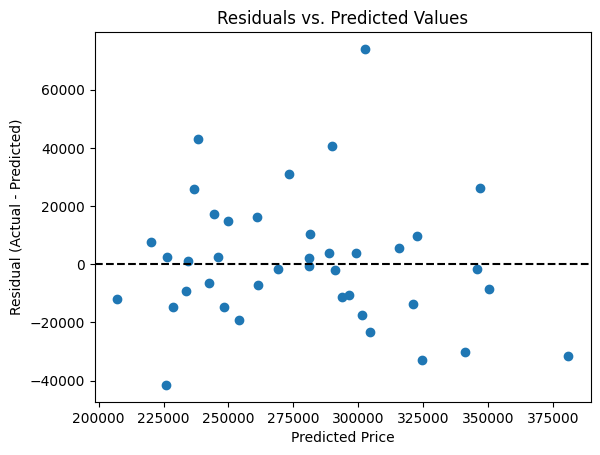

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_pred_test, results["residual"])
plt.axhline(y=0, color="black", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs. Predicted Values")
plt.show()

Ideal residual plot characteristics:
• Points scattered randomly around zero.
• No clear upward or downward trend.
• No curvature.
• Roughly equal vertical spread of residuals across all predicted values.

Key assumptions for simple linear regression:

1. Linearity:
   The relationship between X and Y is linear.

2. Independence:
   Residuals are independent of each other.

3. Homoscedasticity (constant variance):
   Residuals have constant variance across levels of X (or predicted Y).

4. Normality (often assumed for inference):
   Residuals are approximately normally distributed.

Today’s focus: 1, 2, and 3.

Linearity assumption:

The true relationship between X and Y can be approximated by a straight line.

Diagnosing violations:
• Scatterplot of Y vs X.
• Residuals vs predicted plot.

Warning signs:
• Systematic curves in the scatterplot.
• Residual plot with U-shape or inverted U-shape.


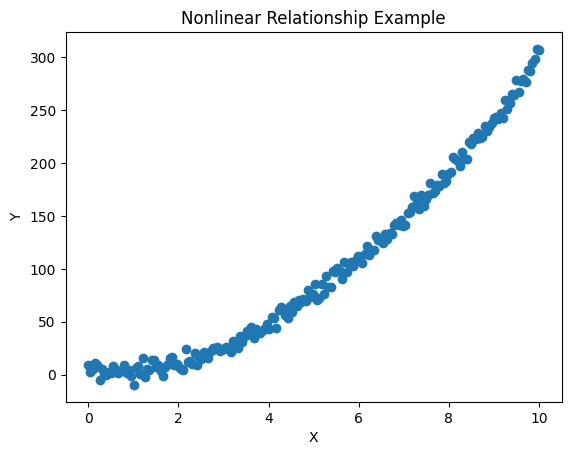

In [ ]:
np.random.seed(0)
X_nl = np.linspace(0, 10, 200)
y_nl = 3 * (X_nl ** 2) + np.random.normal(scale=5, size=200)

df_nl = pd.DataFrame({"X": X_nl, "Y": y_nl})

plt.scatter(df_nl["X"], df_nl["Y"])
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Nonlinear Relationship Example")
plt.show()

Independence:

Residuals should be independent of each other.

Violations:
• Time series: errors correlated over time (autocorrelation).
• Clustered data: multiple observations from same person or unit.

Impacts:
• Underestimated standard errors.
• Overconfident p-values and confidence intervals.

Homoscedasticity:
• Constant variance of residuals across all levels of X or predicted Y.

Heteroscedasticity:
• Variance of residuals changes with X or predicted Y.

Residual plot symptom:
• Funnel shape – residuals fan out or narrow as predictions increase.


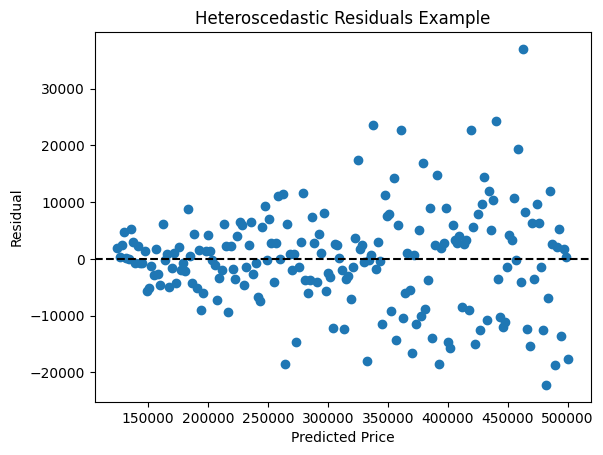

In [ ]:
np.random.seed(42)
X_het = np.linspace(500, 3000, 200)
noise_het = np.random.normal(loc=0, scale=X_het * 5, size=200)  # variance grows with X
y_het = 50000 + 150 * X_het + noise_het

df_het = pd.DataFrame({"square_feet": X_het, "price": y_het})

# Fit a linear model
X_het_feat = df_het[["square_feet"]]
y_het_target = df_het["price"]

model_het = LinearRegression()
model_het.fit(X_het_feat, y_het_target)

y_het_pred = model_het.predict(X_het_feat)
resid_het = y_het_target - y_het_pred

plt.scatter(y_het_pred, resid_het)
plt.axhline(y=0, color="black", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Heteroscedastic Residuals Example")
plt.show()

In [ ]:
Impacts of Violations

Linearity violation:
• Biased predictions in some regions of X.
• Slope may not represent the true relationship.

Independence violation:
• Standard errors too small.
• Overconfident significance tests.

Heteroscedasticity violation:
• Standard errors biased.
• Confidence intervals and hypothesis tests unreliable.